<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Separar variables numéricas y categóricas
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# 1. Normalizar datos numéricos
df_numerical = df[numerical_cols].copy()

# Rellenar valores NaN con el promedio de la columna
for col in df_numerical.columns:
    if df_numerical[col].isnull().any():
        df_numerical[col] = df_numerical[col].fillna(df_numerical[col].mean())

# Inicializar y aplicar MinMaxScaler
scaler = MinMaxScaler()
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_numerical), columns=df_numerical.columns, index=df_numerical.index)

# 2. Procesar variables categóricas con get_dummies
df_categorical = df[categorical_cols].copy()
df_dummies_categorical = pd.get_dummies(df_categorical, dummy_na=False) # dummy_na=False para no crear una columna para NaN

# Explicación de get_dummies:
print("## Explicación de get_dummies:\n")
print("pandas.get_dummies convierte variables categóricas en una representación numérica binaria.")
print("Para cada columna categórica, crea nuevas columnas (dummies). Cada nueva columna")
print("corresponde a una categoría única en la columna original, y el valor es 1 si la fila")
print("pertenece a esa categoría, y 0 en caso contrario. Esto se conoce como 'one-hot encoding'.")
print("Por ejemplo, si 'color' tiene valores 'rojo', 'azul', 'verde', se crearían columnas 'color_rojo', 'color_azul', 'color_verde'.")
print("Cuando el valor original es 'rojo', 'color_rojo' sería 1 y las demás 0.\n")

# 3. Juntar ambos datasets
df_procesado = pd.concat([df_scaled_numerical, df_dummies_categorical], axis=1)

print("DataFrame procesado (primeras 5 filas):")
print(df_procesado.head())
print("\nInformación del DataFrame procesado:")
print(df_procesado.info())


## Explicación de get_dummies:

pandas.get_dummies convierte variables categóricas en una representación numérica binaria.
Para cada columna categórica, crea nuevas columnas (dummies). Cada nueva columna
corresponde a una categoría única en la columna original, y el valor es 1 si la fila
pertenece a esa categoría, y 0 en caso contrario. Esto se conoce como 'one-hot encoding'.
Por ejemplo, si 'color' tiene valores 'rojo', 'azul', 'verde', se crearían columnas 'color_rojo', 'color_azul', 'color_verde'.
Cuando el valor original es 'rojo', 'color_rojo' sería 1 y las demás 0.

DataFrame procesado (primeras 5 filas):
       year  desplazamiento  cilindros       co2  consumo_litros_milla  \
0  0.000000        0.243590   0.142857  0.398014              0.331027   
1  0.000000        0.461538   0.285714  0.527672              0.475113   
2  0.029412        0.243590   0.142857  0.424351              0.360294   
3  0.029412        0.461538   0.285714  0.527672              0.475113   
4  0.088235

### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [12]:
from sklearn.cluster import KMeans

# 1. Ajustar el modelo de kmeans con 8 clusters
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10) # n_init='auto' o un número para evitar warning
kmeans.fit(df_procesado)

# 2. Asociar a cada individuo el correspondiente cluster
df_procesado['cluster'] = kmeans.labels_

# Calcular valor de los centroides de cada cluster
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_procesado.drop('cluster', axis=1).columns)
print("\nCentroides de los clusters (primeras 5 filas):\n")
print(centroids.head())

# 3. Realizar un resumen de las principales cualidades de cada cluster
print("\n### Resumen de las principales cualidades de cada cluster:\n")

# Separar las columnas numéricas y booleanas para el resumen
numerical_cols_processed = df_scaled_numerical.columns
boolean_cols_processed = df_dummies_categorical.columns

for i in range(kmeans.n_clusters):
    cluster_data = df_procesado[df_procesado['cluster'] == i]
    print(f"\n--- Cluster {i} ---")

    # Valor promedio de las variables numéricas
    print("Promedio de variables numéricas:\n")
    print(cluster_data[numerical_cols_processed].mean().to_string())

    # Moda para las variables categóricas (booleanas)
    print("\nModa de variables categóricas (True = predomina, False = no predomina):\n")
    # Para variables booleanas, la moda es True si la mayoría de los valores son True
    # O podemos calcular el porcentaje de True y si es > 0.5, entonces es la moda
    mode_categorical = pd.Series(dtype='object')
    for col in boolean_cols_processed:
        if not cluster_data[col].empty:
            # Calcula la frecuencia de True y False
            true_count = cluster_data[col].sum()
            false_count = len(cluster_data[col]) - true_count
            if true_count > false_count:
                mode_categorical.loc[col] = True
            elif false_count > true_count:
                mode_categorical.loc[col] = False
            else:
                mode_categorical.loc[col] = 'Equal' # En caso de empate
        else:
             mode_categorical.loc[col] = 'N/A' # Si el cluster está vacío para esa columna
    print(mode_categorical.to_string())



Centroides de los clusters (primeras 5 filas):

       year  desplazamiento  cilindros       co2  consumo_litros_milla  \
0  0.427318        0.223790   0.173637  0.304599              0.226412   
1  0.569367        0.169607   0.146057  0.240820              0.156357   
2  0.407666        0.331397   0.256796  0.354288              0.282121   
3  0.476969        0.450984   0.327266  0.410019              0.343261   
4  0.384236        0.585590   0.430797  0.510289              0.454503   

   clase_tipo_Camionetas  clase_tipo_Coche Familiar  \
0               0.126441                   0.097434   
1               0.007990                   0.117281   
2               0.181278                   0.084035   
3               0.304450                   0.017116   
4               0.259250                   0.005599   

   clase_tipo_Coches Grandes  clase_tipo_Coches Medianos  \
0                   0.004835                    0.088137   
1                   0.017606                    0.13840

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

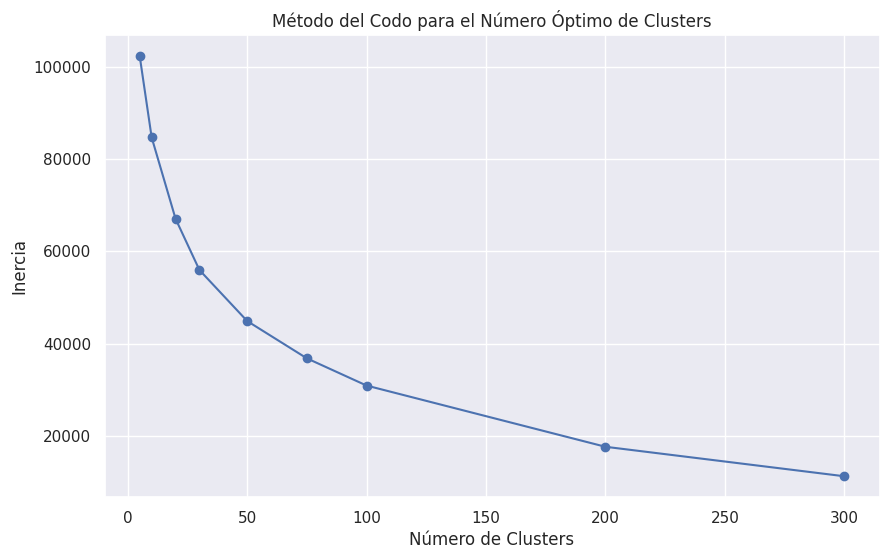

Valores de Inercia para diferentes números de clusters:
Clusters: 5, Inercia: 102310.09
Clusters: 10, Inercia: 84705.94
Clusters: 20, Inercia: 67073.43
Clusters: 30, Inercia: 55953.93
Clusters: 50, Inercia: 44887.89
Clusters: 75, Inercia: 36797.32
Clusters: 100, Inercia: 30896.22
Clusters: 200, Inercia: 17625.99
Clusters: 300, Inercia: 11234.82


In [13]:
inertia = []
list_num_clusters = [5, 10, 20, 30, 50, 75, 100, 200, 300]

# Calculate inertia for each number of clusters
for num_clusters in list_num_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(df_procesado.drop('cluster', axis=1))
    inertia.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(list_num_clusters, inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para el Número Óptimo de Clusters")
plt.grid(True)
plt.show()

print("Valores de Inercia para diferentes números de clusters:")
for num, val in zip(list_num_clusters, inertia):
    print(f"Clusters: {num}, Inercia: {val:.2f}")


Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [6]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [7]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



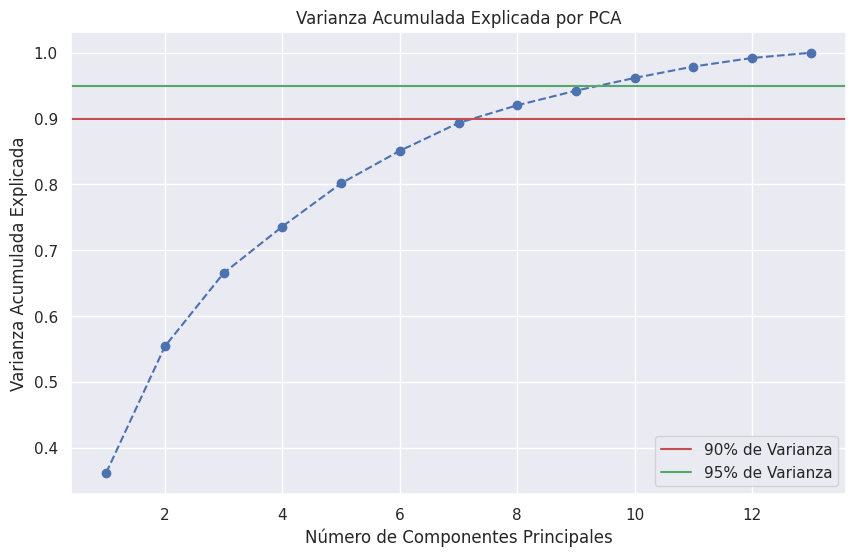


Se necesitan 8 componentes para capturar el 90% de la varianza.

Se necesitan 10 componentes para capturar el 95% de la varianza.

Proyección de las observaciones en las primeras 2 Componentes Principales (primeras 5 filas):

        PC1       PC2  wine_class
0  3.316751  1.443463           0
1  2.209465 -0.333393           0
2  2.516740  1.031151           0
3  3.757066  2.756372           0
4  1.008908  0.869831           0


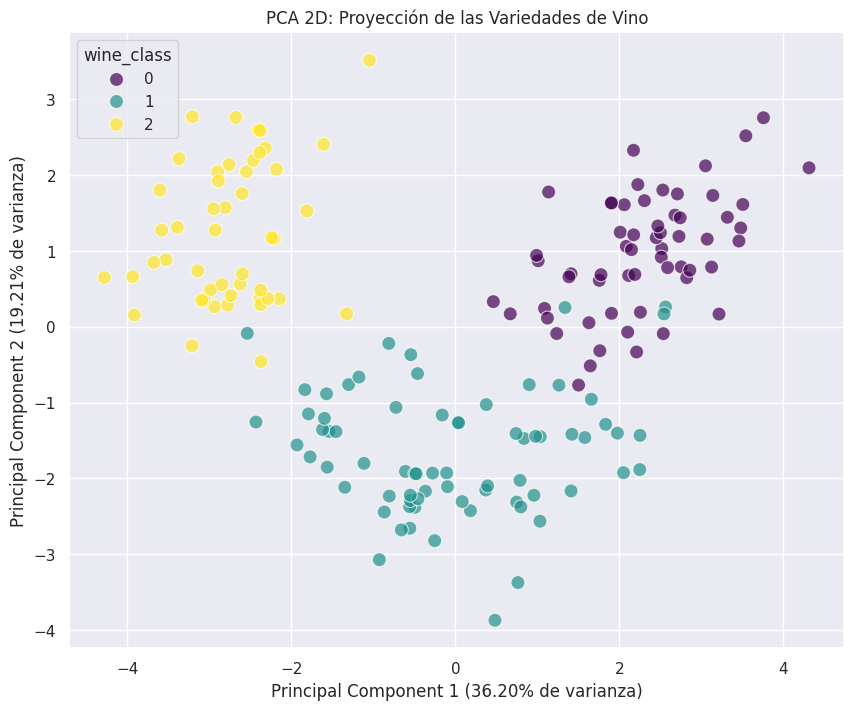


Loadings de las características en las primeras 2 Componentes Principales:

                                   PC1       PC2
alcohol                       0.144329  0.483652
malic_acid                   -0.245188  0.224931
ash                          -0.002051  0.316069
alcalinity_of_ash            -0.239320 -0.010591
magnesium                     0.141992  0.299634
total_phenols                 0.394661  0.065040
flavanoids                    0.422934 -0.003360
nonflavanoid_phenols         -0.298533  0.028779
proanthocyanins               0.313429  0.039302
color_intensity              -0.088617  0.529996
hue                           0.296715 -0.279235
od280/od315_of_diluted_wines  0.376167 -0.164496
proline                       0.286752  0.364903


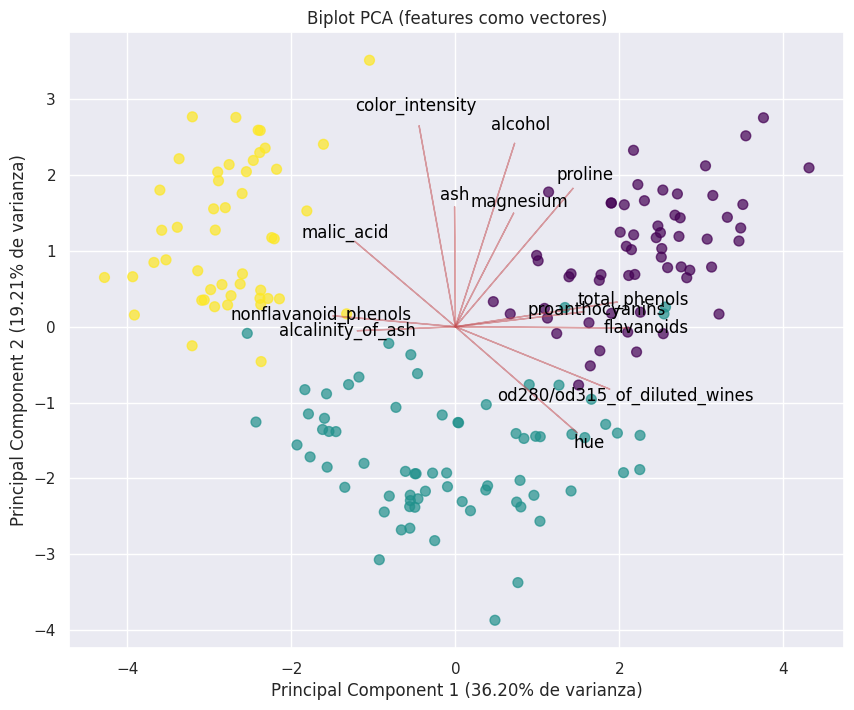

In [15]:
from sklearn.preprocessing import StandardScaler

# Separar las características (X) de las etiquetas de clase (y)
X = wine.drop('wine_class', axis=1)
y = wine['wine_class']

# Estandarizar los datos antes de aplicar PCA (es una buena práctica)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# 1. Calcular la varianza explicada por cada componente principal
pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumsum_explained_variance = np.cumsum(explained_variance_ratio)

# Visualizar el gráfico de varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumsum_explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Acumulada Explicada por PCA')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% de Varianza')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% de Varianza')
plt.grid(True)
plt.legend()
plt.show()

# Identificar cuántos componentes son necesarios para capturar al menos el 90-95% de la información
num_components_90 = np.where(cumsum_explained_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumsum_explained_variance >= 0.95)[0][0] + 1
print(f"\nSe necesitan {num_components_90} componentes para capturar el 90% de la varianza.\n")
print(f"Se necesitan {num_components_95} componentes para capturar el 95% de la varianza.\n")

# 2. Construir tablas y gráficos que muestren cómo las observaciones se proyectan en las primeras componentes principales.
# Reducir a 2 componentes principales para visualización 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y

print("Proyección de las observaciones en las primeras 2 Componentes Principales (primeras 5 filas):\n")
print(df_pca_2d.head())

# Visualizar la proyección en 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='viridis', s=100, alpha=0.7)
plt.title('PCA 2D: Proyección de las Variedades de Vino')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% de varianza)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% de varianza)')
plt.grid(True)
plt.show()

# 3. Analizar los loadings e interpretar qué características químicas del vino tienen mayor influencia
# Loadings para los primeros 2 componentes principales
loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=features)

print("\nLoadings de las características en las primeras 2 Componentes Principales:\n")
print(loadings)

# Visualizar los loadings (biplot, aunque más simple aquí)
plt.figure(figsize=(10, 8))
plt.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], c=df_pca_2d['wine_class'], cmap='viridis', alpha=0.7, s=50)
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings.loc[feature, 'PC1']*5, loadings.loc[feature, 'PC2']*5, color='r', alpha=0.5)
    plt.text(loadings.loc[feature, 'PC1']*5.5, loadings.loc[feature, 'PC2']*5.5, feature, color='black', ha='center', va='center')
plt.title('Biplot PCA (features como vectores)')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% de varianza)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% de varianza)')
plt.grid(True)
plt.show()




### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



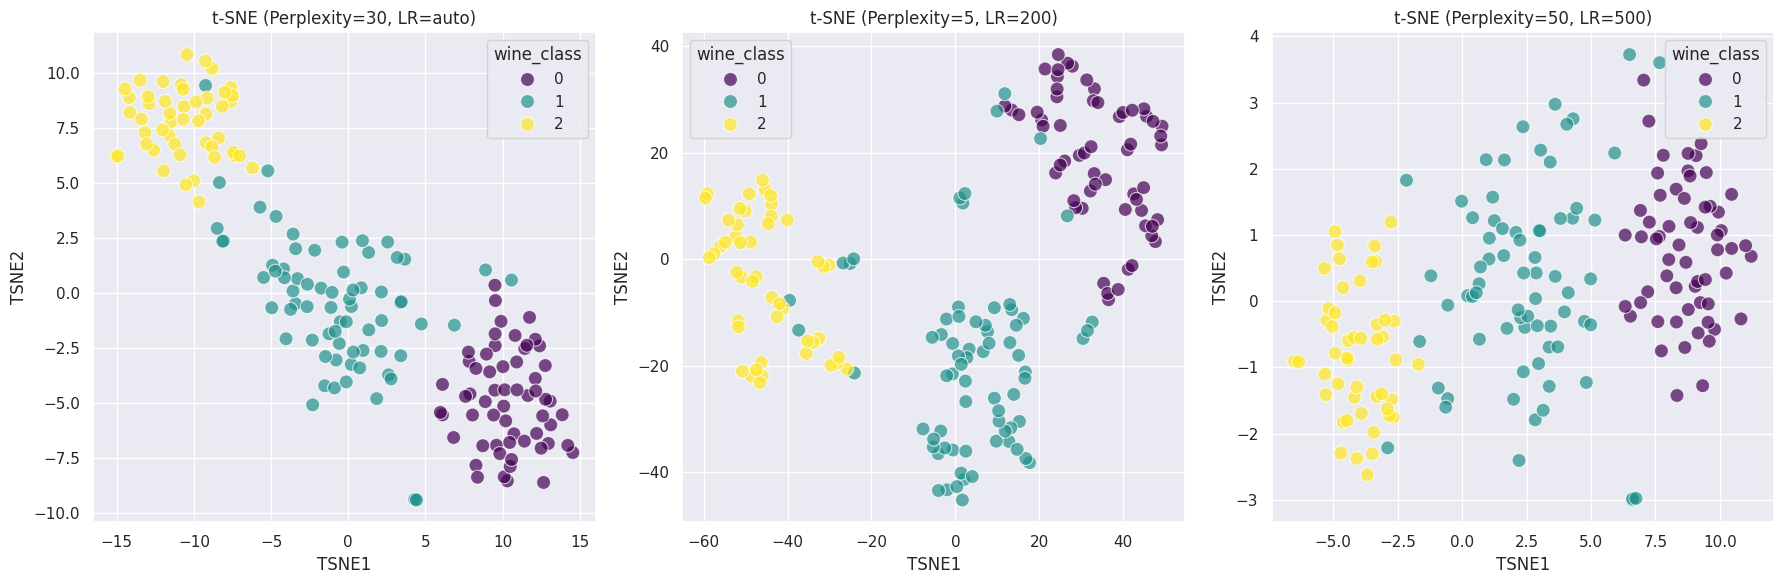


Observaciones sobre los hiperparámetros de t-SNE:

Perplexity: Afecta el balance entre enfocarse en la estructura local y global de los datos.

  - Perplexities más bajas (e.g., 5) se enfocan en detalles locales y pueden resaltar grupos más pequeños.

  - Perplexities más altas (e.g., 50) consideran más vecinos, lo que puede revelar estructuras más grandes y globales.

Learning Rate: Determina el tamaño del paso para la optimización.

  - Un learning rate demasiado bajo puede llevar a una convergencia lenta.

  - Un learning rate demasiado alto puede causar que la optimización 'salte' el mínimo, resultando en una mala representación.

La elección de 'init='pca'' es común para t-SNE, ya que ayuda a una inicialización más estable y reduce el riesgo de resultados subóptimos.


In [16]:
from sklearn.manifold import TSNE

# Probar diferentes configuraciones de hiperparámetros para t-SNE
# Se usarán los datos escalados (X_scaled) para t-SNE

# Configuración 1: Perplexity = 30 (default), Learning rate = auto (default)
tsne_30_auto = TSNE(n_components=2, perplexity=30, learning_rate='auto', random_state=42, init='pca')
X_tsne_30_auto = tsne_30_auto.fit_transform(X_scaled)

df_tsne_30_auto = pd.DataFrame(data=X_tsne_30_auto, columns=['TSNE1', 'TSNE2'])
df_tsne_30_auto['wine_class'] = y

# Configuración 2: Perplexity = 5, Learning rate = 200
tsne_5_200 = TSNE(n_components=2, perplexity=5, learning_rate=200, random_state=42, init='pca')
X_tsne_5_200 = tsne_5_200.fit_transform(X_scaled)

df_tsne_5_200 = pd.DataFrame(data=X_tsne_5_200, columns=['TSNE1', 'TSNE2'])
df_tsne_5_200['wine_class'] = y

# Configuración 3: Perplexity = 50, Learning rate = 500
tsne_50_500 = TSNE(n_components=2, perplexity=50, learning_rate=500, random_state=42, init='pca')
X_tsne_50_500 = tsne_50_500.fit_transform(X_scaled)

df_tsne_50_500 = pd.DataFrame(data=X_tsne_50_500, columns=['TSNE1', 'TSNE2'])
df_tsne_50_500['wine_class'] = y

# Visualizar las diferentes configuraciones
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=df_tsne_30_auto, palette='viridis', s=100, alpha=0.7)
plt.title('t-SNE (Perplexity=30, LR=auto)')
plt.grid(True)

plt.subplot(1, 3, 2)
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=df_tsne_5_200, palette='viridis', s=100, alpha=0.7)
plt.title('t-SNE (Perplexity=5, LR=200)')
plt.grid(True)

plt.subplot(1, 3, 3)
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=df_tsne_50_500, palette='viridis', s=100, alpha=0.7)
plt.title('t-SNE (Perplexity=50, LR=500)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nObservaciones sobre los hiperparámetros de t-SNE:\n")
print("Perplexity: Afecta el balance entre enfocarse en la estructura local y global de los datos.\n")
print("  - Perplexities más bajas (e.g., 5) se enfocan en detalles locales y pueden resaltar grupos más pequeños.\n")
print("  - Perplexities más altas (e.g., 50) consideran más vecinos, lo que puede revelar estructuras más grandes y globales.\n")
print("Learning Rate: Determina el tamaño del paso para la optimización.\n")
print("  - Un learning rate demasiado bajo puede llevar a una convergencia lenta.\n")
print("  - Un learning rate demasiado alto puede causar que la optimización 'salte' el mínimo, resultando en una mala representación.\n")
print("La elección de 'init=\'pca\'' es común para t-SNE, ya que ayuda a una inicialización más estable y reduce el riesgo de resultados subóptimos.")




### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



In [18]:
print("### Comparación entre PCA y t-SNE\n")

print("**PCA (Principal Component Analysis):**\n")
print("- **Naturaleza:** Técnica de reducción de dimensionalidad lineal.\n")
print("- **Enfoque:** Busca las direcciones (componentes principales) que capturan la máxima varianza en los datos.\n")
print("- **Ventajas:** Excelente para comprender la varianza global y las relaciones entre características (loadings). Es determinista y computacionalmente más rápido para grandes conjuntos de datos.\n")
print("- **Limitaciones:** Puede no capturar estructuras complejas y no lineales en los datos, ya que proyecta los datos en un subespacio lineal de menor dimensión.\n")
print("- **Casos de Uso:** Compresión de datos, reducción de ruido, ingeniería de características y como paso de preprocesamiento para otros algoritmos de aprendizaje automático, especialmente cuando se desea la interpretabilidad de los componentes.\n")

print("**t-SNE (t-distributed Stochastic Neighbor Embedding):**\n")
print("- **Naturaleza:** Técnica de reducción de dimensionalidad no lineal.\n")
print("- **Enfoque:** Su objetivo es preservar las vecindades y relaciones locales, lo que la hace eficaz para visualizar datos de alta dimensión en 2D o 3D.\n")
print("- **Ventajas:** Muy eficaz para revelar clústeres y estructuras intrínsecas en conjuntos de datos complejos que PCA podría pasar por alto.\n")
print("- **Limitaciones:** Puede ser computacionalmente intensiva, especialmente para conjuntos de datos muy grandes. No es determinista (los resultados pueden variar ligeramente entre ejecuciones sin un estado aleatorio fijo) y menos interpretable que PCA, ya que sus componentes no tienen un significado claro en términos de las características originales. La optimización de hiperparámetros (como perplexity y learning rate) influye significativamente en los resultados.\n")
print("- **Casos de Uso:** Análisis de datos exploratorio, visualización de clústeres de alta dimensión y evaluación de la calidad de las incrustaciones.\n")

print("**Diferencias clave y aplicación:**\n")
print("- **Lineal vs. No lineal:** PCA es lineal, t-SNE es no lineal.\n")
print("- **Estructura global vs. local:** PCA se centra en la varianza global; t-SNE se centra en preservar las proximidades locales.\n")
print("- **Interpretabilidad:** Los componentes de PCA son interpretables a través de los loadings; los ejes de t-SNE no son directamente interpretables.\n")
print("- **Costo computacional:** PCA es generalmente más rápido; t-SNE es más lento.\n")

print("**En el contexto del conjunto de datos `wine`:**\n")
print("- **PCA** proporcionó una buena separación de las clases de vino, especialmente con los dos primeros componentes principales, lo que indica que una parte significativa de la varianza (y, por lo tanto, la separación de clases) puede explicarse mediante combinaciones lineales de características. Su fortaleza reside en reducir eficientemente las dimensiones manteniendo la mayor parte de la varianza de los datos.\n")
print("- **t-SNE** logró formar clústeres aún más distintos y compactos para las tres clases de vino, destacando su capacidad para descubrir relaciones no lineales y estructuras locales que diferencian claramente los tipos de vino. Sus hiperparámetros (perplexity, learning rate) fueron cruciales para ajustar la claridad de estas visualizaciones.\n")

print("En última instancia, la elección entre PCA y t-SNE depende del objetivo: use PCA para la reducción general de dimensionalidad, la interpretabilidad y como paso de preprocesamiento; use t-SNE para visualizar la agrupación inherente y las estructuras locales en sus datos.")

### Comparación entre PCA y t-SNE

**PCA (Principal Component Analysis):**

- **Naturaleza:** Técnica de reducción de dimensionalidad lineal.

- **Enfoque:** Busca las direcciones (componentes principales) que capturan la máxima varianza en los datos.

- **Ventajas:** Excelente para comprender la varianza global y las relaciones entre características (loadings). Es determinista y computacionalmente más rápido para grandes conjuntos de datos.

- **Limitaciones:** Puede no capturar estructuras complejas y no lineales en los datos, ya que proyecta los datos en un subespacio lineal de menor dimensión.

- **Casos de Uso:** Compresión de datos, reducción de ruido, ingeniería de características y como paso de preprocesamiento para otros algoritmos de aprendizaje automático, especialmente cuando se desea la interpretabilidad de los componentes.

**t-SNE (t-distributed Stochastic Neighbor Embedding):**

- **Naturaleza:** Técnica de reducción de dimensionalidad no lineal.

- **Enfoque:** Su obje